In [1]:
(* This notebook illustrates the construction of several linear ID model from Radia's RK numerical trajectory computation and Elleaume's potential *)
(* The RK integrator is wrapped to model ID as a thin nonlinear insertion in canonical variables *)
(* Interface to use build-in WM ODE solver is provided for slope based equations of motion and canonical equations with optional normalized external vector potentials *)
(* The Utilities section contains utility functions required to construct the linear ID model from Radia RK tracking or from Elleaume's potential or perfom tracking *)
(* The linear transport matrix is computed using both approaches for a simple APPLE-II model adopted from Radia's examples *)

(* Ivan Morozov and Bruno Diviacco, 2025-2026 *)

In [7]:
(* The ID is modeled as a thin nonlinear insertion using the following steps: *)

(* 1. Given an initial condition in canonical coordinates at the ID center *)
(* 2. Propagate the initial condition to the ID entrance using a negative-drift propagator (near zero-field location before the ID) *)
(* 3. Apply entrance angle correctors *)
(* 4. Convert canonical coordinates to slopes using zero-field region relations *)
(* 5. Propagate to the ID exit using Radia's RK integrator or another slope-based integrator with a matching API *)
(* 6. Convert slopes to momenta using zero-field region relations *)
(* 7. Apply exit angle correctors *)
(* 8. Propagate back to the ID center using a negative drift *)

(* These steps represent the effect of an ID as a thin nonlinear insertion *)
(* See the transport function for details *)

In [18]:
(* Linear ID model representation (thin lens insertion at the magnet center) *)

(* (qx, px, qy, py) -> d(qx, px, qy, py)/dδ dp + exp(S A) exp(S B δ) (qx, px, qy, py) *)

(* S                        -- skew symplectic identity matrix *)
(* δ                        -- energy/momentum deviation *)
(* d(qx, px, qy, py)/dδ     -- energy-dependent reference orbit *)
(* exp(S A)                 -- on-energy transverse transport matrix (exponential form), Aij = Aji *)
(* exp(S B dp)              -- leading-order chromatic matrix, Bij = Bji *)

In [25]:
(* Linear ID model computation steps (Radia's RK) *)

(* 1. Given a thin nonlinear insertion mapping (black box mapping zero to zero) *)
(* 2. Compute the energy-dependent reference orbit *)
(* 3. Compute the on-energy transport matrix using small deviations *)
(* 4. Perform transport matrix symplectification and factorization *)
(* 5. Compute the derivative of the transport matrix with respect to energy deviation *)
(* 6. Compute the leading-order chromatic matrix *)

In [32]:
(* Linear ID model computation steps (Elleaume's potential) *)

(* 1. Given the Radia magnet model *)
(* 2. Define a single-kick (or one-kick-per-period) nonlinear thin insertion mapping *)
(* 3. Compute relevant quantities following the above Radia's RK workflow (no reference-orbit correction or chromatic-orbit change for this case) *)

In [36]:
(* Linear ID model (Elleaume's potential and semi-parametric transport matrix for all periods) *)

(* 1. Given the Radia magnet model *)
(* 2. Compute focusing and defocusing parameters from potentials for one ID period *)
(* 3. Use a (semi-)parametric ID transport matrix to compute the transport matrix and chromatic effects *)

In [40]:
(* Set library path *)

wolflib = Environment["WOLFLIB"];
current = Environment["LD_LIBRARY_PATH"] ;
SetEnvironment["LD_LIBRARY_PATH" -> wolflib <> ":" <> current] ;
Environment["LD_LIBRARY_PATH"] ;

In [45]:
(* Load Radia *)

<< Radia` ; 

Radia Version: 4.32 is loaded
Radia is copyright ESRF, France.
Portions copyright Synchrotron SOLEIL, France.
Portions copyright Wolfram Research, Inc.


In [47]:
(* Load utility functions (or execute Utilities section) *)

<< matrix` ;

# Utilities

In [49]:
(* --------- RadFldPtcTrj --------- *)

ClearAll[RadFldPtcTrj] ;
Options[RadFldPtcTrj] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}
} ;
RadFldPtcTrj::usage="RadFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np] -- compute transverse coordinates and its derivatives (angles/slopes) of a relativistic charged particle trajectory in 3D magnetic field produced by the object obj, using the NDSolve interface (see default method options). The particle energy is E [GeV], initial transverse coordinates and derivatives are {x0, dxdy0, z0, dzdy0}; the longitudinal coordinate y is varied from y0 to y1 in np steps. All positions are in millimeters and angles in radians." ;
RadFldPtcTrj[obj_, E_, {x0_, dxdy0_, z0_, dzdy0_}, {y0_, y1_}, np_, options:OptionsPattern[]] := Block[
	{alpha, bx, by, bz, system, x, xp, z, zp, xi, xpi, zi, zpi, y, solver, table, functions, positions},
	alpha = (0.299792458/E)/1000.0 ;
	bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := bx[x, y, z] = radFld[obj, "bx", {x, y, z}] ;
	by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := by[x, y, z] = radFld[obj, "by", {x, y, z}] ;
	bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := bz[x, y, z] = radFld[obj, "bz", {x, y, z}] ;
	system = {
		x'[y] == xp[y],
		z'[y] == zp[y],
		xp'[y] == -alpha/Sqrt[1 + xp[y]^2 + zp[y]^2]*(zp[y]*by[x[y], y, z[y]] + (1 + xp[y]^2)*bz[x[y], y, z[y]] + xp[y]*zp[y]*bx[x[y], y, z[y]]),
		zp'[y] == +alpha/Sqrt[1 + xp[y]^2 + zp[y]^2]*(xp[y]*by[x[y], y, z[y]] + (1 + zp[y]^2)*bx[x[y], y, z[y]] + xp[y]*zp[y]*bz[x[y], y, z[y]]),
		x[y0] == xi,
		xp[y0] == xpi,
		z[y0] == zi,
		zp[y0] == zpi
	} ;
	solver = ParametricNDSolveValue[
		system,
		{x, xp, z, zp},
		{y, y0, y1},
		{xi, xpi, zi, zpi},
		Method -> OptionValue[Method],
		StartingStepSize -> (y1 - y0)/np,
		MaxStepSize  -> (y1 - y0)/np
	] ;
	functions = solver[x0, dxdy0, z0, dzdy0] ;
	positions = Subdivide[y0, y1, np - 1] ;
	Map[Flatten, Transpose[{positions, Map[Function[{position}, Through[functions[position]]], positions]}]]
] ;

(* --------- RadFldPtcTrjCnn --------- *)

ClearAll[RadFldPtcTrjCnn];
Options[RadFldPtcTrjCnn] = {
	"Delta" -> {0.1, 0.1},
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}
} ;
RadFldPtcTrjCnn::usage="RadFldPtcTrjCnn[obj, E, dE, {qx0, px0, qz0, pz0}, {y0, y1}, np, {extAx, extAy, extAz}] -- compute transverse canonical coordinates of a relativistic charged particle trajectory in 3D magnetic field produced by the object obj, using the NDSolve interface (see default options). The particle energy is E [GeV], initial transverse canonical coordinates are {qx0, px0, qz0, pz0}; the longitudinal coordinate y is varied from y0 to y1 in np steps. All positions are in millimeters." ;
RadFldPtcTrjCnn[obj_, E_, dE_, {qx0_, px0_, qz0_, pz0_}, {y0_, y1_}, np_, {extAx_, extAy_, extAz_}, options : OptionsPattern[]] := Block[
	{alpha, Ax, Ay, Az, ax, ay, az, daxdx, daydx, dazdx, daxdz, daydz, dazdz, hx, hz, flow, system, y, qx, qz, px, pz, qxi, qzi, pxi, pzi, solver, functions, positions},
	alpha = -(0.299792458/E)/1000.0 ;
	Ax[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Ax[x, y, z] = radFld[obj, "ax", {x, y, z}] ;
	Ay[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Ay[x, y, z] = radFld[obj, "ay", {x, y, z}] ;
	Az[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Az[x, y, z] = radFld[obj, "az", {x, y, z}] ;
	ax[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Ax[x, y, z] + extAx[x, y, z] ;
	ay[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Ay[x, y, z] + extAy[x, y, z] ;
	az[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Az[x, y, z] + extAz[x, y, z] ;
	daxdx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daxdx[x, y, z] = (ax[x + hx, y, z] - ax[x - hx, y, z])/(2 hx) ;
	daydx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daydx[x, y, z] = (ay[x + hx, y, z] - ay[x - hx, y, z])/(2 hx) ;
	dazdx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := dazdx[x, y, z] = (az[x + hx, y, z] - az[x - hx, y, z])/(2 hx) ;
	daxdz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daxdz[x, y, z] = (ax[x, y, z + hz] - ax[x, y, z - hz])/(2 hz) ;
	daydz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daydz[x, y, z] = (ay[x, y, z + hz] - ay[x, y, z - hz])/(2 hz) ;
	dazdz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := dazdz[x, y, z] = (az[x, y, z + hz] - az[x, y, z - hz])/(2 hz) ;
	{hx, hz} = OptionValue["Delta"] ;
	flow[qx_, qz_, px_, pz_, y_] := flow[qx, qz, px, pz, y] = Block[
		{axi, ayi, azi, pix, piz, sqrt, daxdxi, daydxi, dazdxi, daxdzi, daydzi, dazdzi, qxdot, qzdot, pxdot, pzdot},
		axi = ax[qx, y, qz] ;
		ayi = ay[qx, y, qz] ;
		azi = az[qx, y, qz] ;
		pix = px - axi ;
		piz = pz - azi ;
		sqrt = Sqrt[(1 + dE)^2 - pix^2 - piz^2] ;
		daxdxi = daxdx[qx, y, qz] ;
		daydxi = daydx[qx, y, qz] ;
		dazdxi = dazdx[qx, y, qz] ;
		daxdzi = daxdz[qx, y, qz] ;
		daydzi = daydz[qx, y, qz] ;
		dazdzi = dazdz[qx, y, qz] ;
		qxdot = pix/sqrt ;
		qzdot = piz/sqrt ;
		pxdot = daydxi + (pix*daxdxi + piz*dazdxi)/sqrt ;
		pzdot = daydzi + (pix*daxdzi + piz*dazdzi)/sqrt ;
		{qxdot, qzdot, pxdot, pzdot}
	] ;
	system = {
		{qx'[y], qz'[y], px'[y], pz'[y]} == flow[qx[y], qz[y], px[y], pz[y], y],
		qx[y0] == qxi,
		px[y0] == pxi,
		qz[y0] == qzi,
		pz[y0] == pzi
	} ;
	solver = ParametricNDSolveValue[
		system,
		{qx, px, qz, pz},
		{y, y0, y1},
		{qxi, pxi, qzi, pzi},
		Method -> OptionValue[Method],
		StartingStepSize -> (y1 - y0)/np,
		MaxStepSize -> (y1 - y0)/np
	] ;
	functions = solver[qx0, px0, qz0, pz0] ;
	positions = Subdivide[y0, y1, np - 1] ;
	Map[Flatten, Transpose[{positions, Map[Function[{position}, Through[functions[position]]], positions]}]]
] ;

(* --------- transport --------- *)

ClearAll[transport] ;
Options[transport] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
transport::usage = "transport[object, energy, delta, {start, stop}, steps, angles, solver][{qx, px, qz, pz}] -- track canonical initial condition (qx, px, qz, pz) with (qx, qz in m) through slope-based solver (x and z in mm)" ;
transport[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_:{0, 0, 0, 0},     (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
][state_] := Block[
	{QX, PX, QZ, PZ, X, XP, Z, ZP, CXI, CZI, CXF, CZF},
	{QX, PX, QZ, PZ} = state ;
	{CXI, CZI, CXF, CZF} = angles ;
	If[
		OptionValue["Thin"],
		{QX, PX, QZ, PZ} = {QX - 1/2*(stop - start)/1000.0*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - 1/2*(stop - start)/1000.0*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	] ;
	{QX, PX, QZ, PZ} = {QX, PX + CXI, QZ, PZ + CZI} ;
    {X, XP, Z, ZP} = {QX, PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], QZ, PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2]} ;
    {X, XP, Z, ZP} = {1000.0*X, XP, 1000.0*Z, ZP} ;
    {X, XP, Z, ZP} = Rest[Last[solver[object, energy*(1 + delta), {X, XP, Z, ZP}, {start, stop}, steps, Sequence @@ FilterRules[options, Options[NDSolve]]]]] ;
    {X, XP, Z, ZP} = {X/1000.0, XP, Z/1000.0, ZP} ;
    {QX, PX, QZ, PZ} = {X, (1 + delta)*XP/Sqrt[1 + XP^2 + ZP^2], Z, (1 + delta)*ZP/Sqrt[1 + XP^2 + ZP^2]} ;
    {QX, PX, QZ, PZ} = {QX, PX + CXF, QZ, PZ + CZF} ;
	If[
		OptionValue["Thin"],
		{QX, PX, QZ, PZ} = {QX - 1/2*(stop - start)/1000.0*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - 1/2*(stop - start)/1000.0*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	] ;
    {QX, PX, QZ, PZ}
] ;

(* --------- amplitude --------- *)

ClearAll[amplitude] ;
Options[amplitude] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
amplitude::usage = "amplitude[object, component, period, reference, harmonic, options] -- compute the amplitude of the n-th fourier harmonic of given periodic field component over one longitudinal period centered at given reference point using trapezoidal rule " ;
amplitude[                    (* -- amplitude *)
    object_,                  (* -- radia object *)
    component_,               (* -- field component *)
    period_,                  (* -- longitudinal period (mm) *)
    reference_,               (* -- reference point (mm) *)
    harmonic_,                (* -- harmonic number *)
    options:OptionsPattern[]  (* -- options *)
] := Block[
    {count, fields, weights, range, angles, cos, sin},
    count = If[OptionValue["Samples"] === Automatic, harmonic*OptionValue["SamplesPerHarmonic"], OptionValue["Samples"]] ;
    fields = radFldLst[object, component, reference - {0, period/2, 0}, reference + {0, period/2, 0}, count] ;
    weights = ConstantArray[1.0, count] ;
    weights[[+1]] = 0.5 ;
    weights[[-1]] = 0.5 ;
    range = Range[0, count - 1] ;
    angles = 2*Pi*harmonic*range/(count - 1) ;
    cos = (2/(count - 1))*Total[weights*fields*Cos[angles]] ;
    sin = (2/(count - 1))*Total[weights*fields*Sin[angles]] ;
    Sqrt[cos^2 + sin^2]
] ;

(* --------- Elleaume potential (periodic field) --------- *)

ClearAll[potential] ;
Options[potential] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
potential::usage = "potential[object, {x, z}, periods, harmonics, shift, options] -- compute Elleaume one-(super)period potenial " ;
potential[                    (* -- potential (T^2 mm^3 *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{period, length, hx, hz, bx, bz},
  period = Max[periods] ;
  {hx, hz} = Round[period/periods] ;
  bx = Table[amplitude[object, "bx", period, {x, shift, z}, hx*harmonic, Sequence @@ FilterRules[{options}, Options[amplitude]]], {harmonic, harmonics}] ;
  bz = Table[amplitude[object, "bz", period, {x, shift, z}, hz*harmonic, Sequence @@ FilterRules[{options}, Options[amplitude]]], {harmonic, harmonics}] ;
  0.5*period*(period/(2*Pi))^2*Total[(bx^2/hx^2 + bz^2/hz^2)/harmonics^2]
] ;

(* --------- horizontal slope kick (period) --------- *)

ClearAll[dxp] ;
Options[dxp] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
dxp::usage = "dxp[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute one-(super) period horizontal angle kick (murad) using central finite difference" ;
dxp[                          (* -- one-(super) period horizontal angle kick (murad) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb},
    pa = potential[object, {x - delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x + delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5*(0.299792458/energy)^2
] ;

(* --------- vertical slope kick (period) --------- *)

ClearAll[dzp] ;
Options[dzp] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
dzp::usage = "dzp[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute one-(super) period vertical angle kick (murad) using central finite difference" ;
dzp[                          (* -- one-(super) period vertical angle kick (murad) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb},
    pa = potential[object, {x, z - delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z + delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5*(0.299792458/energy)^2
] ;

(* --------- horizontal focusing strength (period) --------- *)

ClearAll[kx] ;
Options[kx] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
kx::usage = "kx[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute horizontal focusing strength using central finite difference" ;
kx[                           (* -- horizontal focusing strength (1/m) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb, pc},
    pa = potential[object, {x - delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pc = potential[object, {x + delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    10.0^-3*4*(pa - 2*pb + pc)/delta^2*0.5*(0.299792458/energy)^2
] ;

(* --------- vertical focusing strength (period) --------- *)

ClearAll[kz] ;
Options[kz] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
kz::usage = "kx[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute vertical focusing strength using central finite difference" ;
kz[                           (* -- vertical focusing strength (1/m) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb, pc},
    pa = potential[object, {x, z - delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pc = potential[object, {x, z + delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    10.0^-3*4*(pa - 2*pb + pc)/delta^2*0.5*(0.299792458/energy)^2
] ;

(* --------- dkd potential based tracking --------- *)

ClearAll[dkd] ;
Options[dkd] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
dkd::usage = "dkd[object, energy, delta, periods, harmonics, shift, step, count, factors, options][{qx, px, qz, pz}] -- drift-kick-drift canonical tracking (period in mm, x and z in m)" ;
dkd[                          (* -- rdrift-kick-drift canonical tracking *)
	object_,                  (* -- radia object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy delta *)
	periods_,                 (* -- horizontal and vertival periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
	harmonics_,               (* -- list of harmonics *)
	shift_,                   (* -- longitudinal shift/position (mm) *)
	step_,                    (* -- finite difference delta (mm) *)
	count_,                   (* -- total number of (super) periods *)
	factors_:{1.0, 1.0},      (* -- extra kick multiplicaton factors *)
    options:OptionsPattern[]  (* -- options *)
][state_] := Block[
    {FX, FZ, QX, PX, QZ, PZ, X, XP, Z, ZP, DL},
    {FX, FZ} = factors ;
    {QX, PX, QZ, PZ} = state ;
    DL = Max[periods]/2/10.0^3 ;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
    Do[
		{QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
		{X, XP, Z, ZP} = {QX, PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], QZ, PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2]} ;
		{X, XP, Z, ZP} = {
			X,
			XP - FX*dxp[object, 10.0^3*{X, Z}, periods, harmonics, shift, energy*(1 + delta), step, Sequence @@ FilterRules[{options}, Options[potential]]]*10^-6,
			Z,
			ZP - FZ*dzp[object, 10.0^3*{X, Z}, periods, harmonics, shift, energy*(1 + delta), step, Sequence @@ FilterRules[{options}, Options[potential]]]*10^-6
		} ;
		{QX, PX, QZ, PZ} = {X, (1 + delta)*XP/Sqrt[1 + XP^2 + ZP^2], Z, (1 + delta)*ZP/Sqrt[1 + XP^2 + ZP^2]} ;
		{QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ},
		count
	] ;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	{QX, PX, QZ, PZ}
] ;

(* --------- explicit ID transport matrix (appoximate) --------- *)

ClearAll[idtm] ;
idtm::usage = "idtm[{kx, kz}, {np, lp}, dp] -- compute id thin insertion exponent diagonal and corresponding transport matrix (second order in kx and kz)" ;
idtm[                         (* -- id thin insertion diagonal and transport matrix *)
	{kx_, kz_},               (* -- focusing strength (1/m) *)
	count_,                   (* -- total number of (super) periods *)
	period_,                  (* -- (super) period length (m) *)
	delta_                    (* -- energy delta *)
] := Block[
	{a, b, c, d, diagonal, matrix},
	a = (kx*count)/(1 + delta) - (kx^2*period*count*(-1 + count^2))/(6*(1 + delta)^3) ;
	b = (kx*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kx^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	c = (kz*count)/(1 + delta) - (kz^2*period*count*(-1 + count^2))/(6*(1 + delta)^3); 
	d = (kz*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kz^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	diagonal = {a, b, c, d} ;
	matrix = MatrixExp[{{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} . DiagonalMatrix[diagonal]] ;
	{diagonal, matrix}   
] ;

(* --------- symplectic identity matrix --------- *)

ClearAll[identity] ;
identity[dimension_] := KroneckerProduct[IdentityMatrix[dimension], {{0, 1}, {-1, 0}}] ;

(* --------- symplectify --------- *)

ClearAll[symplectify] ;
symplectify::usage = "symplectify[matrix] -- symplectify given matrix (symplectic projection)" ;
symplectify[matrix_] := Block[
  {size, dimension, E, S, V, W},
  size = Length[matrix] ;
  dimension = 1/2*size ;
  E = IdentityMatrix[size] ;
  S = identity[dimension] ;
  V = S.(E - matrix).LinearSolve[E + matrix, E] ;
  W = 1/2*(V + Transpose[V]) ;
  LinearSolve[S + W, S - W]
] ;

(* --------- transport matrix --------- *)

ClearAll[matrix] ;
Options[matrix] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
matrix::usage = "matrix[object, energy, delta, {start, stop}, steps, angles, epsilon, solver] -- compute transport matrix " ;
matrix[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_,                  (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	epsilon_,                 (* -- epsilon initial condition *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
] := Block[
	{initial, positive, negative},
	positive = transport[object, energy, delta, {start, stop}, steps, angles, solver, options] /@ (+ epsilon*IdentityMatrix[4]) ;
	negative = transport[object, energy, delta, {start, stop}, steps, angles, solver, options] /@ (- epsilon*IdentityMatrix[4]) ;
	Transpose[(positive - negative)/(2*epsilon)]
] ;

(* --------- transport matrix (parameterization) --------- *)

ClearAll[parameterize] ;
Options[parameterize] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
parameterize::usage = "parameterize[object, energy, delta, {start, stop}, steps, angles, epsilon, solver] -- parameterize transport matrix" ;
parameterize[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_,                  (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	epsilon_,                 (* -- epsilon initial condition *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
] := Block[
	{transport, symplectic, positive, negative, derivative, identity, A, B},
	transport = matrix[object, energy, 0.0, {start, stop}, steps, epsilon, solver, options] ;
	symplectic = symplectify[transport] ;
	positive = matrix[object, energy, +delta, {start, stop}, steps, angles, epsilon, solver, options] ;
	negative = matrix[object, energy, -delta, {start, stop}, steps, angles, epsilon, solver, options] ;
	derivative = (positive - negative)/2/delta ;
	identity = {{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} ;
	A = Re[- identity . MatrixLog[symplectic]] ;
	B = - identity . MatrixExp[- identity . A] . derivative ;
	{transport, symplectic, A, B, 1/2 (B + Transpose[B])}
] ;

# Accuracy

In [120]:
(* Set desired accuracy *)

accuracy = 10.^-12 ;
options = {PrcB, PrcA, PrcBInt, PrcForce, PrcTorque, PrcEnergy, PrcCoord, PrcAngle} ;
radFldCmpPrc @@ Thread[options -> ConstantArray[accuracy, Length[options]]] ;

# Magnet

In [124]:
(* Simle APPLE-II ID Radia model *)

In [125]:
(* ID construction primitives *)

ClearAll[array] ;
array[
	center_,      (* magnet center *)
	wv_,          (* magnet v-block sizes *)
	wh_,          (* magnet h-block sizes *)
	np_,          (* number of periods *)
	lp_,          (* period length *)
	remanence_,   (* remanent field *)
	helicity_,    (* magnetization direction *)
	tilt_: 0      (* tilt angle *)
] := Block[
	{i, object, local, weight, width, angle, magnetization},
	object = radObjCnt[{}] ;
	local = center - {0, 1/2*np*lp, 0} ;
	For[
		i = 0, i < 4*np + 1, i++,
		weight = If[i == 0 || i == 4*np, 0.5, 1.0] ;
		width = If[Mod[i, 2] == 0, wv, wh] ;
		angle = -(i - 1)*Pi/2*helicity ;
		magnetization = {Sin[tilt]*Sin[angle], Cos[angle], Cos[tilt]*Sin[angle]}*remanence*weight ; 
		radObjAddToCnt[object, {radObjRecMag[local, width, magnetization]}] ;
		local = local + {0, lp/4, 0} ;
	] ;
	object
] ;

ClearAll[apple] ;
apple[
	center_,      (* magnet center *)
	gap_,         (* vertical gap  *)
	gapx_,        (* horizontal gap *)
	phase_,       (* longitudinal phase shift *)
	lx_,          (* magnet block horizontal length *)
	lz_,          (* magnet block vertical length *)
	airgap_,      (* air gap *)
	np_,          (* number of periods= *)
	lp_,          (* period length *)
	remanence_    (* remanent field *)
] :=  Block[{wv, wh, px, pz},
	wv = {lx/2, lp/4 - airgap, lz} ;
	wh = wv ;
	px = lx/4 + gapx/2 ;
	pz = gap/2 + lz/2 ;
	radObjCnt[
		{
			array[center + {+px, +phase/2, +pz}, wv, wh, np, lp, +remanence, +1],
			array[center + {-px, -phase/2, +pz}, wv, wh, np, lp, +remanence, +1],
			array[center + {+px, -phase/2, -pz}, wv, wh, np, lp, -remanence, -1],
			array[center + {-px, +phase/2, -pz}, wv, wh, np, lp, -remanence, -1]
		}
	]
] ;

In [130]:
(* ID parameters *)

np = 32 ;          (* Number of periods *)
lp = 88 ;          (* Undulator Period in [mm] *)
gap = 10 ;         (* Magnetic Gap in[mm] *)
gapx = 1 ;         (* Horizontal gap between magnet arrays in [mm] *)
phase = lp/4 ;     (* Phase in [mm] *)
lx = 60 ;          (* Total Horizontal width of the magnet array in [mm] *)
lz = 12 ;          (* Vertical height of the magnet blocks *)
airgap = 0 ;       (* Longitudinal airgap between magnets in [mm] *)
remanence = 1.2 ;  (* Remanent field of the magnet blocks in [T] *)

In [140]:
(* Computation *)
(* Note, random variations are turned off after solving *)

radFldLenRndSw["on"] ;

center = {0.0, 0.0, 0.0} ;
magnet = apple[center, gap, gapx, phase, lx, lz, airgap, np, lp, remanence] ;

radFldLenRndSw["off"] ;

bx         by   bz
1    0.656677   0.   0.562646

2    0.656677   0.   0.562646

3    0.656801   0.   0.562652

4    0.656801   0.   0.562652

5    0.657322   0.   0.564434

6    0.657322   0.   0.564434

7    0.657322   0.   0.564434

8    0.657322   0.   0.564434

9    0.657328   0.   0.564464

10   0.657328   0.   0.564464

11   0.657328   0.   0.564464

12   0.657328   0.   0.564464

13   0.657328   0.   0.564465

14   0.657328   0.   0.564465

15   0.657328   0.   0.564465

16   0.657328   0.   0.564465

17   0.657328   0.   0.564465

18   0.657328   0.   0.564465

19   0.657328   0.   0.564465

20   0.657328   0.   0.564465

21   0.657328   0.   0.564465

22   0.657328   0.   0.564465

23   0.657328   0.   0.564465

24   0.657328   0.   0.564465

25   0.657328   0.   0.564465

26   0.657328   0.   0.564465

27   0.657328   0.   0.564465

28   0.657328   0.   0.564465

29   0.657328   0.   0.564465

30   0.657328   0.   0.564465

31   0.657328   0.   0.564465

32   0.657328   0.   0.564465
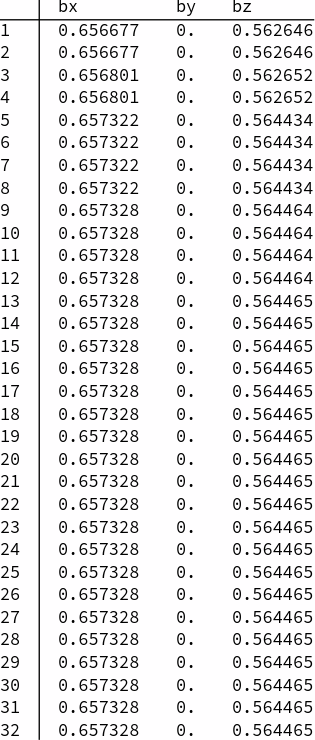

In [146]:
(* Harmonics (amplitude) convergence *)

harmonics = Range[32] ;
TableForm[
	N[Chop[Transpose[Sqrt[Map[Accumulate, Transpose[Table[amplitude[magnet, "b", lp, center, harmonic, "SamplesPerHarmonic" -> 64], {harmonic, harmonics}]]^2]]], 10.0^-6]],
	TableHeadings -> {harmonics, {"bx", "by", "bz"}}
]

In [149]:
(* Field graphics *)

ClearAll[bx, by, bz] ; 
bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bx", {x, y, z}] ;
by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "by", {x, y, z}] ;
bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bz", {x, y, z}] ;

ClearAll[b] ;
b[x_, y_, z_] := {bx[x, y, z], by[x, y, z], bz[x, y, z]} ;

field = VectorPlot3D[
  b[x, y, z],
  {x, -0.75*lx, +0.75*lx}, {y, -lp/2, +lp/2}, {z, -1.5*lz, +1.5*lz},
  VectorPoints -> {16, 64, 8},
  Lighting -> "Neutral",
  VectorScale -> {Small, 0.2, None},
  VectorStyle -> Directive[{Opacity[0.25]}],
  VectorColorFunction -> Hue,
  ColorFunctionScaling -> True
] ;

graphics = Show[Graphics3D[{EdgeForm[None], LightBlue, Opacity[0.25], radObjDrw[magnet]}, PlotRange -> {All, {-lp/2, +lp/2}, All}, ImageSize -> 1000], field, Boxed -> False] ;

# Integration parameters

In [158]:
(* Define min and max positions (mm) where field can be negnected *)

shift = 1000.0 ;
ymin = - lp*np/2 - shift ;
ymax = + lp*np/2 + shift ;

Chop[{radFld[magnet, "bx", {0.0, ymin, 0.0}], radFld[magnet, "by", {0.0, ymin, 0.0}], radFld[magnet, "bz", {0.0, ymin, 0.0}]}, 10.0^-6]
Chop[{radFld[magnet, "bx", {0.0, ymax, 0.0}], radFld[magnet, "by", {0.0, ymax, 0.0}], radFld[magnet, "bz", {0.0, ymax, 0.0}]}, 10.0^-6]

{0, 0, 0}
{0, 0, 0}

In [164]:
(* Define integration step length (mm) and number of integration steps *)
(* Note, the integration step size is very small here, this is done for illustrative purposes *)
(* For practical computations, it can be increased significantly to reduce computation time *)

step = 0.25 ;
ypts = Floor[(ymax - ymin)/step] ;

# Lattice parameters

In [169]:
(* Reference enegry (GeV) *)

energy = 3.0 ;

In [171]:
(* Twiss parameters at ID (m) *)
(* Note, not used in this demo *)

bx$id = 8.0 ;
by$id = 2.0 ;

# Orbit matching

In [175]:
(* Orbit matching corrections *)
(* In general, a zero initial condition at the min longitudinal position will not be mapped to zero at the max longitudinal position *)
(* This is due to the mean orbit not aligning with the field symmetry axes *)
(* A correction to enforce a zero-to-zero mapping can be computed by solving a fixed point problem *)
(* These corrections (and the resulting mismatch) are normally very small and can be neglected (their effect on the transport matrix is also small) *)
(* Effects from real construction errors is expected to be much stronger *)
(* Additionally, they might take a long time to compute depending on the ID geometry complexity *)

In [182]:
(* Compute corrections *)

ClearAll[corrections] ;
corrections[object_, energy_, delta_, {start_, stop_}, steps_, solver_:radFldPtcTrj][{cxi_, czi_, cxf_, czf_}] := Block[
	{qx, px, qz, pz},
	{qx, px, qz, pz} = {0.0, 0.0, 0.0, 0.0} ;
	{qx, px, qz, pz} = {qx, px + cxi, qz, pz + czi} ;
	{qx, px, qz, pz} = transport[object, energy, delta, {start, stop}, steps, {0.0, 0.0, 0.0, 0.0}, solver, "Thin" -> False][{qx, px, qz, pz}] ;
	{qx, px, qz, pz} = {qx, px + cxf, qz, pz + czf} ;
	{qx, px, qz, pz}
] ;

ClearAll[angles] ;
ClearAll[cxi, czi, cxf, czf] ;

solution = FindRoot[
	corrections[magnet, energy, 0.0, {ymin, ymax}, ypts][{cxi, czi, cxf, czf}] == 0, 
	{{cxi, 0.0}, {czi, 0.0}, {cxf, 0.0}, {czf, 0.0}}, 
	Evaluated -> False,
	Compiled -> False
] ;

angles = {cxi, czi, cxf, czf} = {cxi, czi, cxf, czf} /. solution ;
angles

-7            -10            -7             -10
{2.49062 10  , 6.83348 10   , 2.49062 10  , -6.83488 10   }

In [190]:
(* Set correction values to skip long comutation *)

ClearAll[angles] ;
ClearAll[cxi, czi, cxf, czf] ;

angles = {cxi, czi, cxf, czf} = {2.4906259041062194*^-7, 6.831144216727172*^-10, 2.4906284546525633*^-7, -6.835463939423848*^-10} ;

In [194]:
(* Test corrections matching *)

initial = {0.0, 0.0, 0.0, 0.0} ;
transport[magnet, energy, 0.0, {ymin, ymax}, ypts, 0.0*angles, radFldPtcTrj, "Thin" -> True][initial] - initial // Abs // Chop // N
transport[magnet, energy, 0.0, {ymin, ymax}, ypts, 1.0*angles, radFldPtcTrj, "Thin" -> True][initial] - initial // Abs // Chop // N

-9            -7            -9            -10
{4.88356 10  , 5.16014 10  , 3.79759 10  , 3.10146 10   }
{0., 0., 0., 0.}

# Reference trajectory

In [198]:
(* radFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np]      -- Radia RK integration          *)
(* RadFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np]      -- NDSolve integration           *)
(* RadFldPtcTrjCnn[obj, E, dE, {qx0, px0, qz0, pz0}, {y0, y1}, np] -- NDSolve canonical integration *)

{0., 0., 0., 0.}
                         -7             -6           -10
{-0.00123768, -2.66951 10  , -3.05075 10  , -3.734 10   }
-Graphics-   -Graphics-
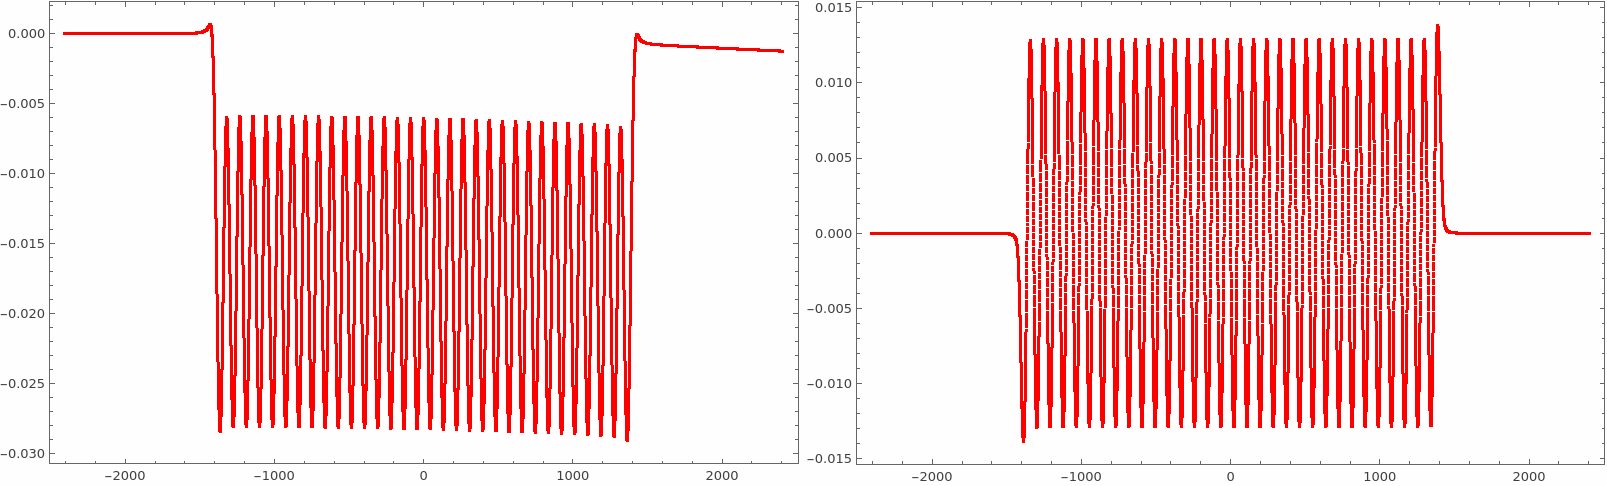

In [201]:
(* Ideal on-energy orbit (no matching) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0}
initial = initial + 0.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[radFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts]] ;
Map[Last, {xs, xps, zs, zps}] + 1.0*{0.0, cxf, 0.0, czf} // Chop // N

pltx = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
Grid[{{Show[pltx, PlotRange -> All], Show[plty, PlotRange -> All]}}]

{0., 0., 0., 0.}
           -10                 -9
{8.26955 10   , 0., -1.05472 10  , 0.}
-Graphics-   -Graphics-
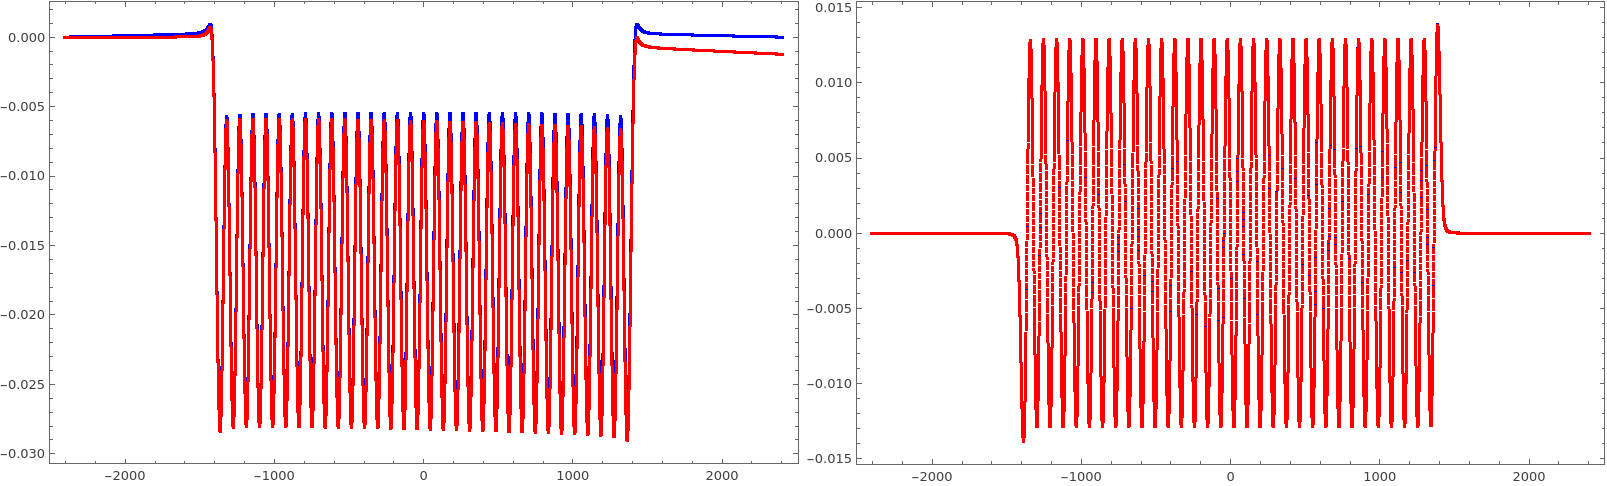

In [210]:
(* Ideal on-energy orbit (matching) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0}
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[radFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts]] ;
Map[Last, {xs$matched, xps$matched, zs$matched, zps$matched} = {xs, xps, zs, zps}] + 1.0*{0.0, cxf, 0.0, czf} // Chop // N

pltx$matched = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty$matched = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-
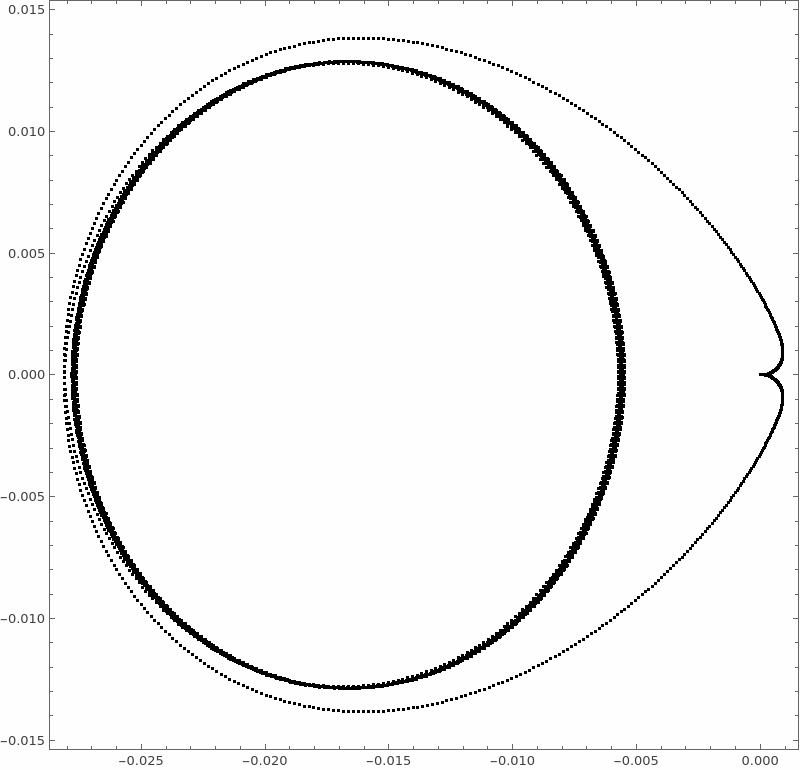

In [219]:
(* Plot x vs z *)

ListPlot[Transpose[{xs, zs}],  PlotStyle -> Black,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False, AspectRatio -> 1]

In [221]:
(* Plot 3D trajectory (magnified) *)

ClearAll[bx, by, bz] ; 
bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bx", {x, y, z}] ;
by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "by", {x, y, z}] ;
bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bz", {x, y, z}] ;

ClearAll[b] ;
b[x_, y_, z_] := {bx[x, y, z], by[x, y, z], bz[x, y, z]} ;

field = VectorPlot3D[
  b[x, y, z],
  {x, -0.75*lx, +0.75*lx}, {y, -lp/2, +lp/2}, {z, -1.5*lz, +1.5*lz},
  VectorPoints -> {16, 32, 8},
  Lighting -> "Neutral",
  VectorScale -> {Small, 0.25, None},
  VectorStyle -> Directive[{Opacity[0.50]}],
  VectorColorFunction -> Hue,
  ColorFunctionScaling -> True
] ;

factor = 250.0 ;

graphics = Show[
	Graphics3D[{EdgeForm[None], LightBlue, Opacity[0.25], radObjDrw[magnet]}, PlotRange -> {All, {-lp/2, +lp/2}, All}, ImageSize -> 1000], 
	ListPointPlot3D[Transpose[{factor*xs, positions, factor*zs}]],
	field,
	Boxed -> False
] ;

-Graphics-   -Graphics-
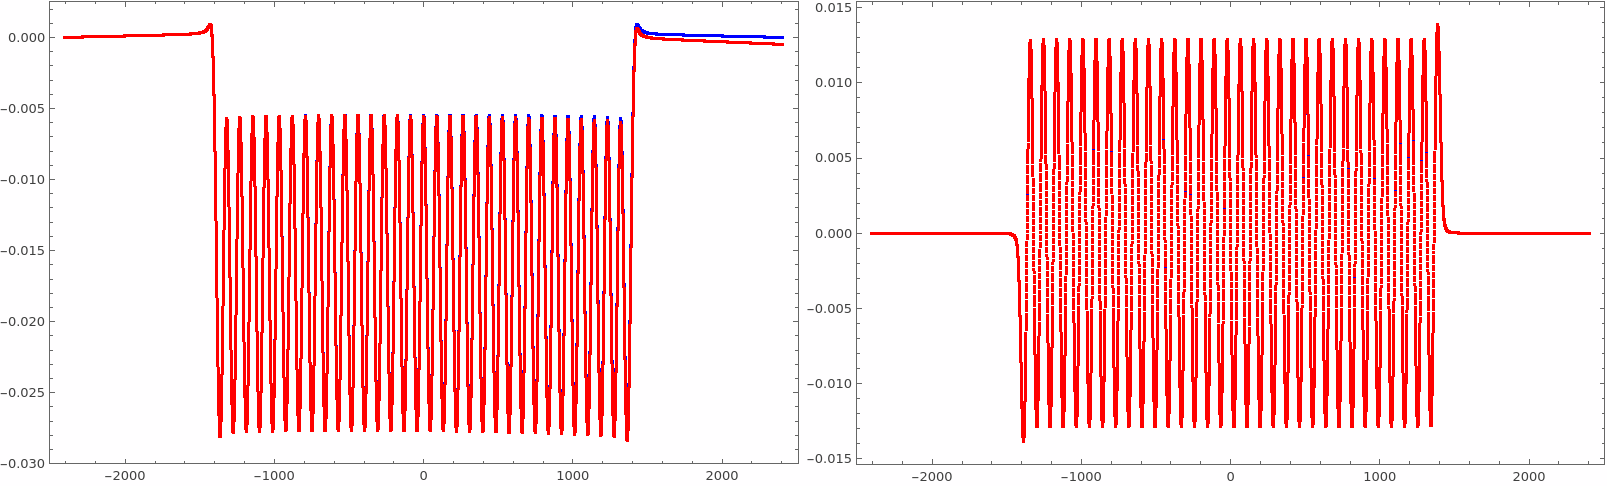

In [231]:
(* Integrate ideal on-energy orbit (NDSolve) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[RadFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts, Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}]] ;

pltx = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-   -Graphics-
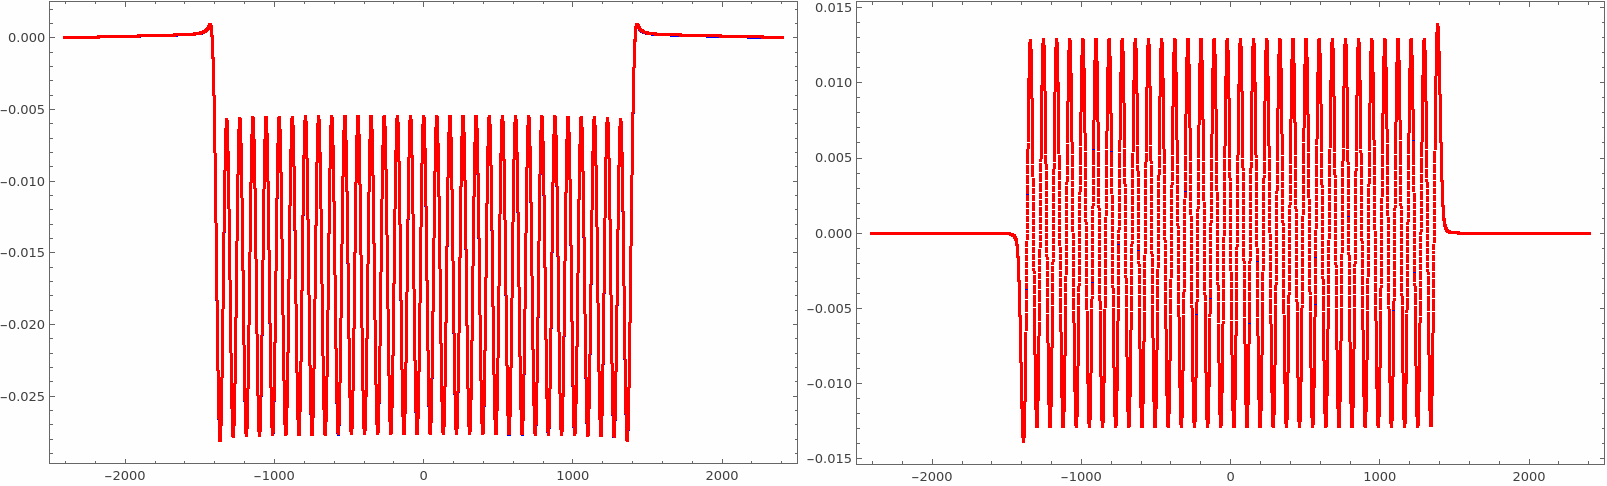

In [239]:
(* Integrate ideal on-energy orbit (NDSolve & canonical tracking) *)
(*  Note, external fields are assumed to be normalized *)

ClearAll[extAx, extAy, extAz] ;
extAx[x_, y_, z_] := 0.0 ;
extAy[x_, y_, z_] := 0.0 ;
extAz[x_, y_, z_] := 0.0 ;

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, qxs, pxs, qzs, pzs} = Transpose[RadFldPtcTrjCnn[magnet, energy, delta, initial, {ymin, ymax}, ypts, {extAx, extAy, extAz}, Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}]] ;

pltx = ListPlot[Transpose[{positions, qxs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, qzs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-   -Graphics-
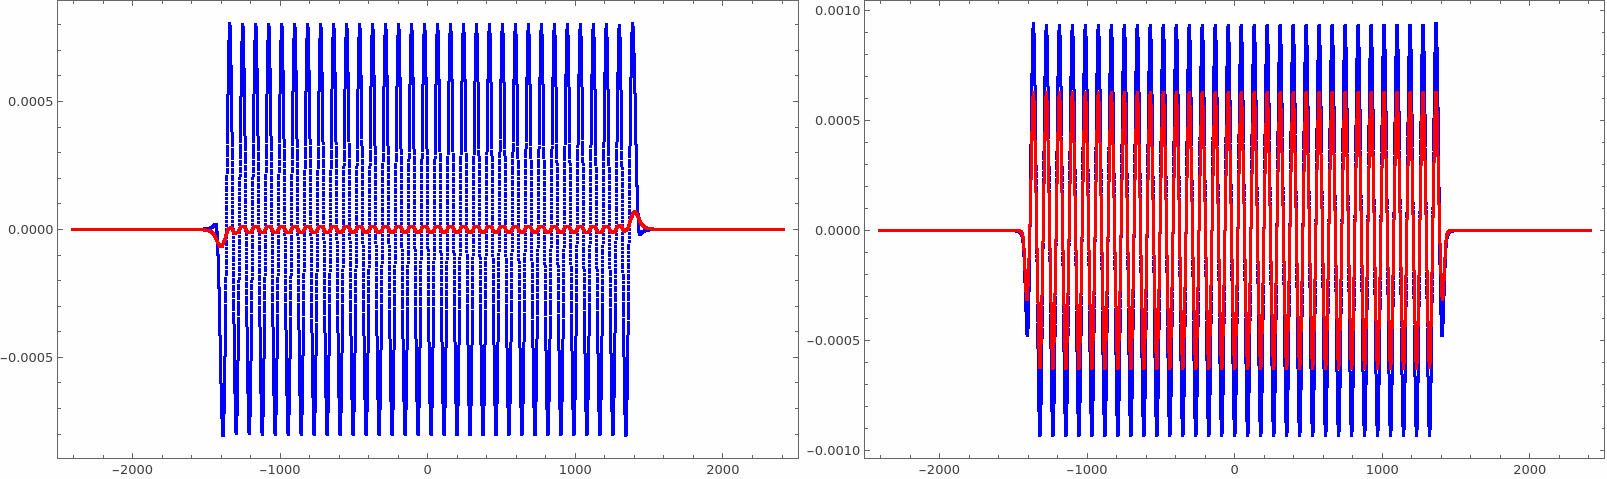

In [252]:
(* Slopes vs canonical momenta *)

pltx$matched = ListPlot[Transpose[{positions, xps$matched}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty$matched = ListPlot[Transpose[{positions, zps$matched}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

pltx = ListPlot[Transpose[{positions, pxs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, pzs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

In [258]:
(* For some reason, canonical tracking matches Radia's RK results much better *)
(* The integration method used, or the step size, does not seem to resolve the discrepancy when using RadFldPtcTrj (slope-based solver) *)
(* If you know the reason why RadFldPtcTrj does not match Radia\[CloseCurlyQuote]s RK well, send me an email. Cheers! *)

# Tracking (Elleaume's potential)

In [261]:
(* The DKD function can be used to perform canonical tracking using Elleaume's potential *)
(* Similarly to RK based tracking, canonical coordinates are used and the element is represented as a thin nonlinear insertion *)
(* Each ID period is a drift\[Dash]kick\[Dash]drift sequence, where the kick angles are computed from the Elleaume's potential *)
(* Unlike kick maps, the kick angles are not precomputed on a grid, but are computed on demand given the transverse coordinates *)
(* In all computations first four harmonics are used with number of samples 32 x harmonic number *)

In [266]:
(* Set the on-orbit canonical initial condition for tracking comparison *)
(* This canonical initial condition corresponds to the ID center *) 
(* Coordinates are in meters *)

delta = 0.0 ;
initial = {0.25, 0.0, 0.25, 0.0}*10.0^-3 ;

In [271]:
(* Compute final value with radFldPtcTrj solver *)

final = transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial]

-6                          -6
{0.000250159, 7.4999 10  , 0.000250078, -9.82598 10  }

In [273]:
(* Potential tracking (single kick at the ID center) *)
(* Here, the dxp and dzp angles are computed explicitly for one ID period and multiplied by the number of periods *)
(* Input coordinates are in mm and the output angles are in microradians *)

{qx, px, qz, pz} = initial ;
{x, xp, z, zp} = {qx, px/Sqrt[(1 + delta)^2 - px^2 - pz^2], qz, pz/Sqrt[(1 + delta)^2 - px^2 - pz^2]} ;
cx = np*dxp[magnet, 10.0^3*{x, z}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy*(1 + delta), 0.1, "SamplesPerHarmonic" -> 32]*10^-6 ;
cz = np*dzp[magnet, 10.0^3*{x, z}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy*(1 + delta), 0.1, "SamplesPerHarmonic" -> 32]*10^-6 ;
{x, xp, z, zp} = {x, xp - cx, z, zp - cz} ;
{qx, px, qz, pz} = {x, (1 + delta)*xp/Sqrt[1 + xp^2 + xp^2], z, (1 + delta)*zp/Sqrt[1 + xp^2 + zp^2]} ;
final$1k = {qx, px, qz, pz} ;

final$1k - final // Abs

-7           -8           -8            -7
{1.59206 10  , 2.7639 10  , 7.7705 10  , 2.70368 10  }

In [284]:
(* Equivalently, the computation can be performed using the DKD function *)
(* With number of periods set to one and extra angle multiplication factors set to the number of periods *)

final$1k = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32][initial] ;
final$1k - final // Abs

-7           -8           -8            -7
{1.59206 10  , 2.7639 10  , 7.7705 10  , 2.70368 10  }

In [288]:
(* Perform tracking using one kick per ID period *)

final$nk = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32][initial] ;
final$1k - final // Abs
final$nk - final // Abs

-7           -8           -8            -7
{1.59206 10  , 2.7639 10  , 7.7705 10  , 2.70368 10  }
           -7            -8           -7            -8
{2.32106 10  , 7.57775 10  , 2.1247 10  , 7.85553 10  }

# Energy-dependent orbit

In [292]:
(* Compute the orbit derivative with respect to energy deviation using a central finite difference *)
(* This effect is very small even for more realistic IDs models *)

In [294]:
delta = 0.0001 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
positive = transport[magnet, energy, +delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
negative = transport[magnet, energy, -delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
dispersion = (positive - negative)/(2*delta) ;
N[Chop[dispersion, 10.0^-6]]

-6
{0., 1.00341 10  , 0., 0.}

In [300]:
delta = 0.001 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
positive = transport[magnet, energy, +delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
negative = transport[magnet, energy, -delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
dispersion = (positive - negative)/(2*delta) ;
N[Chop[dispersion, 10.0^-6]]

-6
{0., 1.00342 10  , 0., 0.}

In [306]:
ClearAll[wrapper] ;
wrapper[delta_?NumericQ] := transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;

In [308]:
<< NumericalCalculus`
N[Chop[ND[wrapper[δ], δ, 0.0, Method -> "CentralDifference"], 10.0^-6]]

-6
{0., 1.00341 10  , 0., 0.}

# Transport matrix (RK integrator)

In [310]:
(* Given a black-box thin nonlinear insertion mapping, the corresponding transport matrix can be extracted by tracking several initial conditions close to the origin *)
(* The resulting matrix is not symplectic, but it is expected to be close to a symplectic one *)
(* A standard symplectification procedure can then be applied to obtain a symplectic matrix that can be used to model the ID's effect on linear optics *)
(* The exponential representation can be computed from this matrix, yielding a redundancy-free representation and providing a link to the time-one Hamiltonian and monomials with dominant coefficients *)
(* Alternatively, one can proceed without symplectification to compute the exponent and then perform symmetrization *)

In [315]:
(* Set the on-orbit canonical initial condition for tracking comparison *)
(* This canonical initial condition corresponds to the ID center *) 
(* Coordinates are in meters *)

delta = 0.0 ;
initial = {0.25, 0.0, 0.25, 0.0}*10.0^-3 ;

In [320]:
(* Compute final value with radFldPtcTrj solver *)

final = transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial]

-6                          -6
{0.000250159, 7.4999 10  , 0.000250078, -9.82598 10  }

-10
6.76402 10
0.999717        -0.0189308      0.000912086    0.0000197475

0.0299467       0.999717        0.0000298481   -0.000824004

0.000823995     -0.0000197528   0.999486       0.0261814

-0.0000298478   -0.000912076    -0.0392693     0.999486
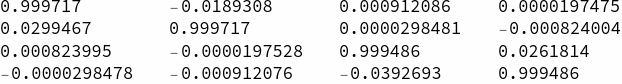

In [322]:
(* Initial transport matrix generation *)
(* Track eight initial conditions epsilon close to the origin using radFldPtcTrj *)

epsilon = 0.00001 ;
M = matrix[magnet, energy, delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
1 - Det[M] // Abs
M // TableForm

-16
1.11022 10
0.999717        -0.0189308      0.000912081    0.0000197443

0.0299467       0.999717        0.0000298477   -0.000823999

0.000823999     -0.0000197499   0.999486       0.0261814

-0.0000298477   -0.000912081    -0.0392693     0.999486
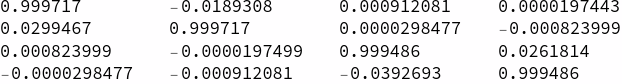

In [328]:
(* Perform transport matrix symplectification *)
(* The minimal linear perturbation corresponds to the identity matrix *)

M = symplectify[M] ;
1 - Det[M] // Abs
M // TableForm

In [333]:
(* Perform transport matrix tracking *)

final$matrix = M.initial ;
final$matrix - final // Abs

-9            -9            -10            -9
{1.96633 10  , 5.76968 10  , 1.60594 10   , 1.19128 10  }

-10             -12
-0.0299495      6.90932 10      9.61582 10      0.000824337

          -10                                              -9
6.90933 10      -0.0189326      0.000912425     -2.79301 10

          -12                                              -9
9.61586 10      0.000912425     0.039276        -3.38251 10

                           -9              -9
0.000824337     -2.79301 10     -3.38251 10     0.0261859
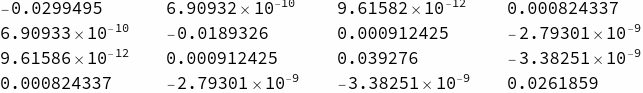

In [336]:
(* Compute transport matrix exponential parameterization M = exp(S A) *)

S = identity[1 + 1] ;
A$RK = - S . MatrixLog[M] // Re ;
A$RK // TableForm

-0.0299495    0.            0.            0.000824337

0.            -0.0189326    0.000912425   0.

0.            0.000912425   0.039276      0.

0.000824337   0.            0.            0.0261859
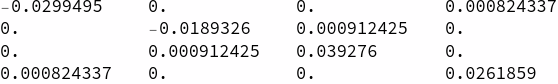

In [340]:
(* For APPLE-II type IDs, the skew-diagonal elements are nonzero, but several orders of magnitude smaller than the main-diagonal ones *)
(* Additionally, the uncoupled blocks are near diagonal, meaning the corresponding uncoupled-block Hamiltonian does not contain cross terms *)
(* In total, 6 parameters are required to parameterize the linear on-energy transport matrix: 4 elements on the main diagonal and 2 on the skew diagonal *)

Chop[A$RK, 10.0^-6] // N // TableForm

In [344]:
(* The corresponding time-one Hamiltonian has a solenoid-like component *)
(* This corresponds to the QX PZ and PX QZ monomial coefficients being nonzero *)

Expand[Chop[1/2 {QX, PX, QZ, PZ} . A$RK . {QX, PX, QZ, PZ}, 10.0^-6]]

2               2                                   2
-0.00946629 PX  + 0.0130929 PZ  + 0.000824337 PZ QX - 0.0149748 QX  + 
 
                                   2
>   0.000912425 PX QZ + 0.019638 QZ

In [347]:
(* To account for chromatic effects, the transport matrix can be factorized as M(δ) = exp(S A) exp(δ S B) exp(δ^2 S C) ... *)
(* The analytical construction can be derived using the Magnus expansion *)
(* Leading-order effects are captured by the B matrix, which is symmetric and in general it has 10 independent elements *)
(* Expanding in a series M(δ) = M(0) + (dM/dδ)(0) δ + ... = M(0) (I + δ S B + ... ) *)
(* Matching the terms gives B = - S exp(-S A) (dM/dδ)(0) *)
(* The derivative (dM/dδ)(0) can be computed by tracking via a central finite difference (dM/dδ)(0) = (M(+\[CapitalDelta]) - M(-\[CapitalDelta]))/(2 \[CapitalDelta]) *)
(* The B matrix should be close to symmetric *)
(* B = 1/2 (B + Transpose[B]) enforces symmetry *)

In [355]:
(* Compute transport matrix derivative with respect to energy deviatino *)

epsilon = 0.0001 ;
delta = 0.0001 ;
positive = matrix[magnet, energy, + delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
negative = matrix[magnet, energy, - delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
dMddp = (positive - negative)/2/delta ;

-6
0.0307692      0.000555884    5.49345 10     -0.00170215

                                                       -6
0.000552915    0.0564279      -0.00176417    5.73185 10

          -6
5.74335 10     -0.00175931    -0.0378706     0.00105693

-0.00169784    0.0000116712   0.00106564     -0.0791863
                                      -6
0.0307692     0.0005544      5.6184 10     -0.00169999

                                                     -6
0.0005544     0.0564279      -0.00176174   8.70153 10

         -6
5.6184 10     -0.00176174    -0.0378706    0.00106128

                        -6
-0.00169999   8.70153 10     0.00106128    -0.0791863
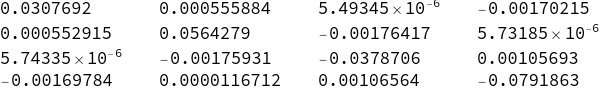
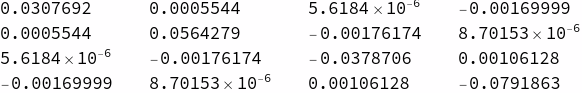

In [361]:
(* Compute the exponent matrix *)
(* As with the orbit derivative, the elements of the leading-order chromatic matrix are rather small *)

B$RK = - S . MatrixExp[- S . A$RK] . dMddp ;
B$RK // TableForm

B$RK = 1/2 (B$RK + Transpose[B$RK]) ; 
B$RK // TableForm

# Transport matrix (Elleaume's potential)

In [367]:
(* Define parametric transport matrix (single kick) *)

ClearAll[m1k] ;
m1k[delta_, epsilon_] := Block[
	{positive, negative},
	positive = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32] /@ (+epsilon*IdentityMatrix[4]) ;
	negative = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32] /@ (-epsilon*IdentityMatrix[4]) ;
	symplectify[Transpose[(positive - negative)/(2*epsilon)]]
] ;

In [370]:
(* Compute on-energy transport matrix and corresponding exponent *)

M$1K = m1k[0.0*delta, epsilon] ;
A$1K = - S . MatrixLog[M$1K] // Re ;

In [373]:
(* Compute leading order chromatic matrix and corresponding exponent *)

positive = m1k[+delta, epsilon] ;
negative = m1k[-delta, epsilon] ;
dMddp = (positive - negative)/2/delta ;

B$1K = - S . MatrixExp[- S . A$1K] . dMddp ;
B$1K = 1/2 (B$1K + Transpose[B$1K]) ; 

In [379]:
(* Define parametric transport matrix (one kick per period) *)

ClearAll[mnk] ;
mnk[delta_, epsilon_] := Block[
	{positive, negative},
	positive = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32] /@ (+epsilon*IdentityMatrix[4]) ;
	negative = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32] /@ (-epsilon*IdentityMatrix[4]) ;
	symplectify[Transpose[(positive - negative)/(2*epsilon)]]
] ;

In [382]:
(* Compute on-energy transport matrix and corresponding exponent *)

M$NK = mnk[0.0*delta, epsilon] ;
A$NK = - S . MatrixLog[M$NK] // Re ;

In [385]:
(* Compute leading order chromatic matrix and corresponding exponent *)

positive = mnk[+delta, epsilon] ;
negative = mnk[-delta, epsilon] ;
dMddp = (positive - negative)/2/delta ;

B$NK = - S . MatrixExp[- S . A$NK] . dMddp ;
B$NK = 1/2 (B$NK + Transpose[B$NK]) ; 

-0.0298529   0.   0.          0.

0.           0.   0.          0.

0.           0.   0.0404091   0.

0.           0.   0.          0.
-0.0302751   0.           0.          0.

0.           -0.0195412   0.          0.

0.           0.           0.0396543   0.

0.           0.           0.          0.0269846
-0.0299495    0.            0.            0.000824337

0.            -0.0189326    0.000912425   0.

0.            0.000912425   0.039276      0.

0.000824337   0.            0.            0.0261859
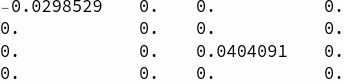
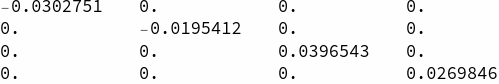
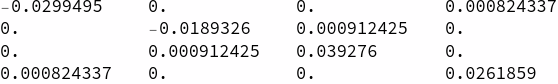

In [391]:
(* Compare results with RK tracking *)

(* Several main observations: *)

(* 1. The matrix computed from a single kick contains only the elements corresponding to focusing strength *)
(* 2. The one-kick-per-period matrix is diagonal *)
(* 3. Its diagonal elements match the RK result closely (this is usually the case for long IDs, for short IDs with matching sections, the difference is more pronounced) *)
(* 4. The skew diagonal, while small, is present only in the RK result *)

Chop[A$1K, 10.0^-6] // N // TableForm
Chop[A$NK, 10.0^-6] // N // TableForm
Chop[A$RK, 10.0^-6] // N // TableForm

0.0298529   0.   0.           0.

0.          0.   0.           0.

0.          0.   -0.0404091   0.

0.          0.   0.           0.
0.0311407     0.000578121   0.           0.

0.000578121   0.0582644     0.           0.

0.            0.            -0.0381965   0.00110166

0.            0.            0.00110166   -0.0815744
                                      -6
0.0307692     0.0005544      5.6184 10     -0.00169999

                                                     -6
0.0005544     0.0564279      -0.00176174   8.70153 10

         -6
5.6184 10     -0.00176174    -0.0378706    0.00106128

                        -6
-0.00169999   8.70153 10     0.00106128    -0.0791863
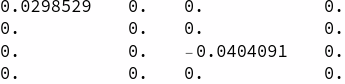
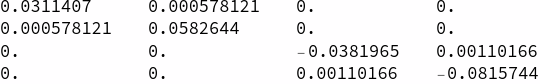
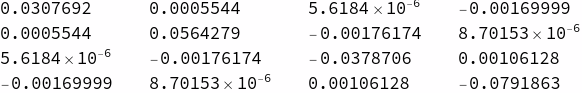

In [400]:
(* Compare leading order chromatic exponents *)

Chop[B$1K, 10.0^-6] // N // TableForm
Chop[B$NK, 10.0^-6] // N // TableForm
Chop[B$RK, 10.0^-6] // N // TableForm

# Transport matrix (approximate linear semi-analytical ID model)

In [404]:
(* Elleaume\[CloseCurlyQuote]s potential can be used to compute the linear focusing parameters kx and kz (note, the mixed derivative is ignored here, it corresponds to linear skew kick) *)
(* This allows constructing a parametric model for the ID transport matrix depending on lp, np, and the focusing parameters *)

In [406]:
(* Compute focusing parameters (one period) *)

KX = kx[magnet, {0.0, 0.0}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy, 0.1, "SamplesPerHarmonic" -> 32]
KZ = kz[magnet, {0.0, 0.0}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy, 0.1, "SamplesPerHarmonic" -> 32]

-0.000933416
0.00126219

In [409]:
np*{KX, KZ}
Diagonal[A$1K]
Diagonal[A$NK]
Diagonal[A$RK]

{-0.0298693, 0.04039}
{-0.0298529, 0., 0.0404091, 0.}
{-0.0302751, -0.0195412, 0.0396543, 0.0269846}
{-0.0299495, -0.0189326, 0.039276, 0.0261859}

In [413]:
(* Compute on-energy transport matrix and corresponding exponent *)
(* In principle, the transport matrix can be computed exactly while keeping the full chromatic dependence *)
(* However, since kx and kz are small, IDTM uses a second-order approximation for the matrix coefficients with respect to the focusing parameters *)

M$ID = idtm[{KX, KZ}, np, lp*10.0^-3, 0.0] // Last ;
A$ID = - S . MatrixLog[M$ID] // Re ;

In [418]:
(* Compute leading order chromatic matrix *)

positive = idtm[{KX, KZ}, np, lp*10.0^-3, +delta] // Last ;
negative = idtm[{KX, KZ}, np, lp*10.0^-3, -delta] // Last ;
dMddp = (positive - negative)/2/delta ;

B$ID = - S . MatrixExp[- S . A$ID] . dMddp ;
B$ID = 1/2 (B$NK + Transpose[B$ID]) ; 

-0.0302751   0.           0.          0.

0.           -0.0195412   0.          0.

0.           0.           0.0396543   0.

0.           0.           0.          0.0269846
-0.0302876   0.          0.          0.

0.           -0.019553   0.          0.

0.           0.          0.0396251   0.

0.           0.          0.          0.0269681
-0.0299495    0.            0.            0.000824337

0.            -0.0189326    0.000912425   0.

0.            0.000912425   0.039276      0.

0.000824337   0.            0.            0.0261859
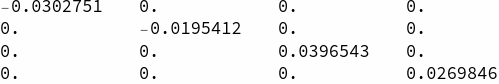
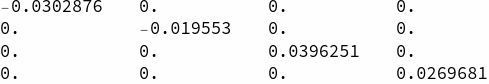
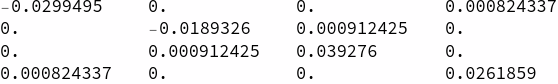

In [424]:
(* Compare on-energy transport matrix exponents *)

Chop[A$NK, 10.0^-6] // N // TableForm
Chop[A$ID, 10.0^-6] // N // TableForm
Chop[A$RK, 10.0^-6] // N // TableForm

0.0311407     0.000578121   0.           0.

0.000578121   0.0582644     0.           0.

0.            0.            -0.0381965   0.00110166

0.            0.            0.00110166   -0.0815744
0.0311383     0.000578506   0.           0.

0.000578506   0.0582919     0.           0.

0.            0.            -0.0381605   0.00110127

0.            0.            0.00110127   -0.081533
                                      -6
0.0307692     0.0005544      5.6184 10     -0.00169999

                                                     -6
0.0005544     0.0564279      -0.00176174   8.70153 10

         -6
5.6184 10     -0.00176174    -0.0378706    0.00106128

                        -6
-0.00169999   8.70153 10     0.00106128    -0.0791863
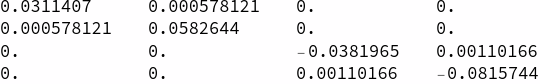
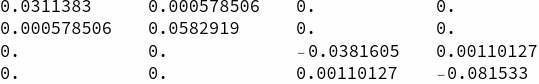
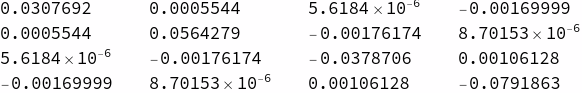

In [428]:
(* Compare leading order chromatic exponents *)

Chop[B$NK, 10.0^-6] // N // TableForm
Chop[B$ID, 10.0^-6] // N // TableForm
Chop[B$RK, 10.0^-6] // N // TableForm